# Qualidade de vinhos | projeto de aprendizado de máquina

**Pergunta:** qual nota sensorial uma amostra receberia a partir de 11 medidas físico-químicas e do tipo de vinho?  
**Saída:** uma nota numérica estimada; portanto, regressão.  
**Uso:** priorizar a segunda degustação humana.

O estudo segue o enunciado da disciplina: auditoria, modelo de referência, métrica, sobreajuste, comparação nas mesmas dobras, teste reservado, erros e restrições de uso. Execute as células em ordem a partir da raiz do repositório ou da pasta projeto. Os gráficos são gerados com Seaborn e Matplotlib, sem arquivos de imagem externos.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_inline.backend_inline import set_matplotlib_formats
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import (
    KFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

SEMENTE = 42
ALVO = "quality"
PASTA_PROJETO = next(
    (p for p in (Path.cwd(), Path.cwd() / "projeto")
     if (p / "dados" / "winequality-red.csv").exists()),
    None,
)
if PASTA_PROJETO is None:
    raise FileNotFoundError("Execute a partir da raiz do repositório ou da pasta projeto.")
PASTA_DADOS = PASTA_PROJETO / "dados"
PASTA_RESULTADOS = PASTA_PROJETO / "resultados"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
set_matplotlib_formats("svg")
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 115, "axes.grid": True, "grid.alpha": 0.25})

print("Python pronto. pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)


Python pronto. pandas: 3.0.5 | scikit-learn: 1.9.1


## 1. Objetivo e auditoria dos dados

Os arquivos públicos Wine Quality reúnem 1.599 vinhos tintos e 4.898 brancos, com 11 medidas físico-químicas e a nota sensorial. Acrescentamos o tipo antes de unir as tabelas. A auditoria verifica ausências, valores inválidos, duplicatas completas e perfis de entrada iguais com notas diferentes. A nota fica fora das variáveis preditoras.


In [2]:
arquivos = {
    "red": PASTA_DADOS / "winequality-red.csv",
    "white": PASTA_DADOS / "winequality-white.csv",
}

tabelas = {}
for tipo, caminho in arquivos.items():
    tabela = pd.read_csv(caminho, sep=";")
    tabela = tabela.apply(pd.to_numeric, errors="raise")
    if tabela.empty or tabela.isna().any().any() or not np.isfinite(tabela.to_numpy()).all():
        raise ValueError(f"Arquivo inválido: {caminho}")
    tabelas[tipo] = tabela

dados_brutos = pd.concat(
    [
        tabelas["red"].assign(wine_type="red"),
        tabelas["white"].assign(wine_type="white"),
    ],
    ignore_index=True,
)
COLUNAS_ENTRADA = [c for c in dados_brutos.columns if c != ALVO]
duplicatas_completas = int(dados_brutos.duplicated().sum())
perfis_conflitantes = int(
    dados_brutos.groupby(COLUNAS_ENTRADA, dropna=False)[ALVO].nunique().gt(1).sum()
)

auditoria = pd.DataFrame(
    {
        "item": [
            "linhas originais", "colunas após wine_type", "células ausentes",
            "duplicatas completas", "perfis iguais com notas diferentes",
            "nota mínima", "nota máxima", "percentual de notas 5 ou 6",
        ],
        "resultado": [
            len(dados_brutos), dados_brutos.shape[1], int(dados_brutos.isna().sum().sum()),
            duplicatas_completas, perfis_conflitantes, dados_brutos[ALVO].min(),
            dados_brutos[ALVO].max(),
            f"{100 * dados_brutos[ALVO].isin([5, 6]).mean():.1f}%",
        ],
    }
)
display(auditoria)
display(dados_brutos.head(3))


,item,resultado
0,linhas originais,6497
1,colunas após wine_type,13
2,células ausentes,0
3,duplicatas completas,1177
4,perfis iguais com notas diferentes,0
5,nota mínima,3
6,nota máxima,9
7,percentual de notas 5 ou 6,76.6%


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red


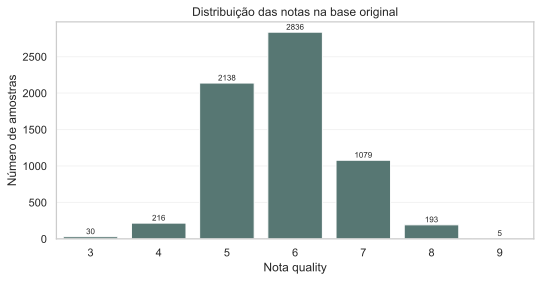

In [3]:
distribuicao = dados_brutos[ALVO].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.4, 3.8), constrained_layout=True)
sns.barplot(x=distribuicao.index.astype(str), y=distribuicao.values, color="#527C77", ax=ax)
ax.set(title="Distribuição das notas na base original", xlabel="Nota quality", ylabel="Número de amostras")
for x, valor in enumerate(distribuicao.values):
    ax.text(x, valor + 35, str(valor), ha="center", fontsize=8)
plt.show()


## 2. Limpeza e divisão

Removemos somente linhas integralmente idênticas antes da divisão para evitar cópias no treino e no teste. Sem identificador de amostra, não é possível afirmar que toda repetição seja erro. Reservamos 20% para teste final estratificado pela nota; seleção e ajuste usam apenas os 80% restantes. A preparação é aprendida dentro de cada dobra do pipeline.


In [4]:
base = dados_brutos.drop_duplicates(keep="first").copy()
X = base.drop(columns=ALVO)
y = base[ALVO]

X_desenvolvimento, X_teste, y_desenvolvimento, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=SEMENTE, stratify=y
)

assert len(base) == 5320
assert len(X_desenvolvimento) == 4256 and len(X_teste) == 1064
assert set(X_desenvolvimento.index).isdisjoint(X_teste.index)

divisao = pd.DataFrame(
    {
        "conjunto": ["Desenvolvimento", "Teste final"],
        "linhas": [len(X_desenvolvimento), len(X_teste)],
        "uso": ["seleção, ajuste e corte", "avaliação final uma vez"],
    }
)
display(divisao)
print("Linhas removidas como duplicatas completas:", len(dados_brutos) - len(base))


,conjunto,linhas,uso
0,Desenvolvimento,4256,"seleção, ajuste e corte"
1,Teste final,1064,avaliação final uma vez


Linhas removidas como duplicatas completas: 1177


## 3. Referência, métrica e validação

A referência prevê a mediana aprendida no treino. O MAE é a métrica principal, em pontos de nota. RMSE destaca erros grandes e R² complementa a leitura. Todos os candidatos usam as mesmas cinco dobras embaralhadas. Regressão linear e k-NN padronizam as medidas dentro do pipeline; árvores não precisam de escala.


In [5]:
COLUNAS_NUMERICAS = [c for c in X.columns if c != "wine_type"]
COLUNAS_CATEGORICAS = ["wine_type"]

def criar_preparacao(padronizar=True):
    return ColumnTransformer(
        [
            ("numericas", StandardScaler() if padronizar else "passthrough", COLUNAS_NUMERICAS),
            (
                "tipo",
                OneHotEncoder(
                    categories=[["red", "white"]], drop="first",
                    sparse_output=False, handle_unknown="error",
                ),
                COLUNAS_CATEGORICAS,
            ),
        ]
    )

def criar_pipeline(modelo, padronizar=True):
    return Pipeline([("preparacao", criar_preparacao(padronizar)), ("modelo", modelo)])

dobras = KFold(n_splits=5, shuffle=True, random_state=SEMENTE)
metricas_cv = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cache_validacao = {}

def avaliar_validacao(nome, modelo):
    chave = repr(modelo)
    if chave in cache_validacao:
        return {"modelo": nome, **cache_validacao[chave]}
    resultado = cross_validate(
        modelo, X_desenvolvimento, y_desenvolvimento,
        cv=dobras, scoring=metricas_cv, return_train_score=True, n_jobs=1,
    )
    erros = -resultado["test_mae"]
    metricas = {
        "MAE treino": -resultado["train_mae"].mean(),
        "MAE VC": erros.mean(),
        "desvio MAE": erros.std(),
        "pior dobra": erros.max(),
        "melhor dobra": erros.min(),
        "RMSE VC": -resultado["test_rmse"].mean(),
        "R² VC": resultado["test_r2"].mean(),
    }
    cache_validacao[chave] = metricas
    return {"modelo": nome, **metricas}


## 4. Complexidade e sobreajuste

A curva da árvore confronta o MAE de treino e validação em profundidades de 1 a 18. O mínimo de validação escolhe a profundidade sem consultar o teste. Também comparamos valores de k no k-NN e tamanhos de floresta nas mesmas dobras.


,profundidade,MAE treino,MAE VC
0,1,0.654,0.655
1,2,0.600,0.607
2,3,0.587,0.597
3,4,0.563,0.584
4,5,0.540,0.582
5,6,0.519,0.585
6,7,0.490,0.590
7,8,0.450,0.606
8,9,0.407,0.623
9,10,0.354,0.638


Profundidade escolhida pela validação: 5


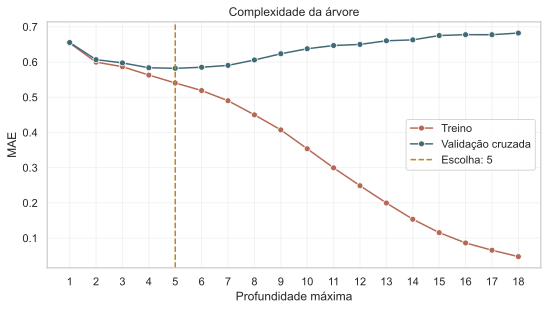

In [6]:
linhas_arvore = []
for profundidade in range(1, 19):
    linha = avaliar_validacao(
        f"profundidade {profundidade}",
        criar_pipeline(
            DecisionTreeRegressor(max_depth=profundidade, random_state=SEMENTE),
            padronizar=False,
        ),
    )
    linha["profundidade"] = profundidade
    linhas_arvore.append(linha)

curva_arvore = pd.DataFrame(linhas_arvore)
profundidade_escolhida = int(curva_arvore.loc[curva_arvore["MAE VC"].idxmin(), "profundidade"])
display(curva_arvore[["profundidade", "MAE treino", "MAE VC"]].round(3))
print("Profundidade escolhida pela validação:", profundidade_escolhida)

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
sns.lineplot(data=curva_arvore, x="profundidade", y="MAE treino", marker="o", label="Treino", color="#B56954", ax=ax)
sns.lineplot(data=curva_arvore, x="profundidade", y="MAE VC", marker="o", label="Validação cruzada", color="#426A76", ax=ax)
ax.axvline(profundidade_escolhida, color="#B8862B", linestyle="--", label=f"Escolha: {profundidade_escolhida}")
ax.set(xticks=range(1, 19), xlabel="Profundidade máxima", ylabel="MAE", title="Complexidade da árvore")
ax.legend()
plt.show()


In [7]:
ajustes = []
for k in [5, 10, 15, 25, 35]:
    linha = avaliar_validacao(
        f"k-NN k={k}",
        criar_pipeline(KNeighborsRegressor(n_neighbors=k, weights="distance")),
    )
    ajustes.append({"família": "k-NN", "configuração": f"k={k}, pesos=distância", "MAE VC": linha["MAE VC"], "parametro": k})

for n_arvores in [100, 350]:
    linha = avaliar_validacao(
        f"Floresta {n_arvores}",
        criar_pipeline(
            RandomForestRegressor(
                n_estimators=n_arvores, max_features=0.7,
                random_state=SEMENTE, n_jobs=1,
            ),
            padronizar=False,
        ),
    )
    ajustes.append({"família": "Floresta", "configuração": f"{n_arvores} árvores, max_features=0.7", "MAE VC": linha["MAE VC"], "parametro": n_arvores})

tabela_ajustes = pd.DataFrame(ajustes)
display(tabela_ajustes.round(3))

k_escolhido = int(tabela_ajustes.loc[tabela_ajustes["família"].eq("k-NN")].nsmallest(1, "MAE VC")["parametro"].iloc[0])
n_arvores_escolhido = int(tabela_ajustes.loc[tabela_ajustes["família"].eq("Floresta")].nsmallest(1, "MAE VC")["parametro"].iloc[0])
print("k escolhido:", k_escolhido, "| número de árvores:", n_arvores_escolhido)


,família,configuração,MAE VC,parametro
0,k-NN,"k=5, pesos=distância",0.560,5
1,k-NN,"k=10, pesos=distância",0.552,10
2,k-NN,"k=15, pesos=distância",0.550,15
3,k-NN,"k=25, pesos=distância",0.551,25
4,k-NN,"k=35, pesos=distância",0.553,35
5,Floresta,"100 árvores, max_features=0.7",0.533,100
6,Floresta,"350 árvores, max_features=0.7",0.531,350


k escolhido: 15 | número de árvores: 350


## 5. Comparação e escolha

Comparamos mediana, regressão linear, k-NN, árvore e floresta pelo MAE nas mesmas cinco dobras. Os hiperparâmetros vêm da etapa anterior. O modelo de menor MAE médio é registrado antes de abrir o teste. Erros de treino baixos em modelos flexíveis não demonstram generalização.


,modelo,MAE treino,MAE VC,desvio MAE,pior dobra,melhor dobra,RMSE VC,R² VC
4,Floresta aleatória,0.195,0.531,0.011,0.547,0.521,0.691,0.381
2,k-NN,-0.000,0.550,0.007,0.562,0.542,0.712,0.342
1,Regressão linear,0.563,0.565,0.015,0.585,0.548,0.733,0.305
3,Árvore,0.540,0.582,0.019,0.619,0.566,0.762,0.248
0,Referência (mediana),0.643,0.643,0.013,0.657,0.626,0.903,-0.056


Escolha congelada antes do teste: Floresta aleatória
Critério: menor MAE médio nas mesmas cinco dobras.


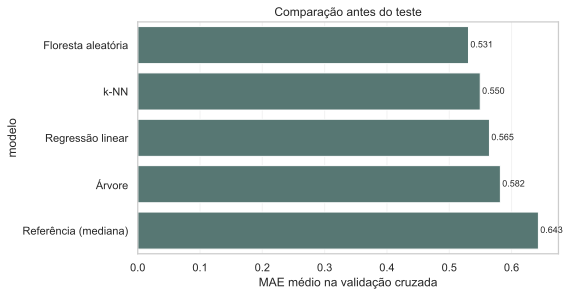

In [8]:
modelos = {
    "Referência (mediana)": criar_pipeline(DummyRegressor(strategy="median"), padronizar=False),
    "Regressão linear": criar_pipeline(LinearRegression()),
    "k-NN": criar_pipeline(KNeighborsRegressor(n_neighbors=k_escolhido, weights="distance")),
    "Árvore": criar_pipeline(
        DecisionTreeRegressor(max_depth=profundidade_escolhida, random_state=SEMENTE),
        padronizar=False,
    ),
    "Floresta aleatória": criar_pipeline(
        RandomForestRegressor(
            n_estimators=n_arvores_escolhido, max_features=0.7,
            random_state=SEMENTE, n_jobs=1,
        ),
        padronizar=False,
    ),
}

comparacao_validacao = pd.DataFrame(
    [avaliar_validacao(nome, modelo) for nome, modelo in modelos.items()]
).sort_values("MAE VC")
display(comparacao_validacao.round(3))

MODELO_ESCOLHIDO = str(comparacao_validacao.iloc[0]["modelo"])
print("Escolha congelada antes do teste:", MODELO_ESCOLHIDO)
print("Critério: menor MAE médio nas mesmas cinco dobras.")

fig, ax = plt.subplots(figsize=(7.8, 4.0), constrained_layout=True)
ordem = comparacao_validacao.sort_values("MAE VC", ascending=True)
sns.barplot(data=ordem, y="modelo", x="MAE VC", color="#527C77", ax=ax)
ax.set(xlabel="MAE médio na validação cruzada", title="Comparação antes do teste")
for y_pos, valor in enumerate(ordem["MAE VC"]):
    ax.text(valor + 0.003, y_pos, f"{valor:.3f}", va="center", fontsize=9)
plt.show()


### Regra de triagem definida no desenvolvimento

Um caso de interesse tem nota real de pelo menos 7. Entre cortes em décimos, escolhemos o maior que preserva sensibilidade mínima de 75% nas previsões fora da dobra do desenvolvimento. Essa regra prioriza recuperar bons candidatos e aceita o custo de degustar falsos positivos.


,corte,sensibilidade,precisão,F1,selecionados
7,5.7,0.926,0.322,0.478,2321
8,5.8,0.902,0.351,0.505,2075
9,5.9,0.857,0.379,0.525,1827
10,6.0,0.809,0.421,0.554,1551
11,6.1,0.739,0.460,0.567,1296
12,6.2,0.654,0.496,0.564,1065
13,6.3,0.565,0.544,0.554,839


Corte congelado antes do teste: 6.0
No desenvolvimento: sensibilidade 80.9% e precisão 42.1%.


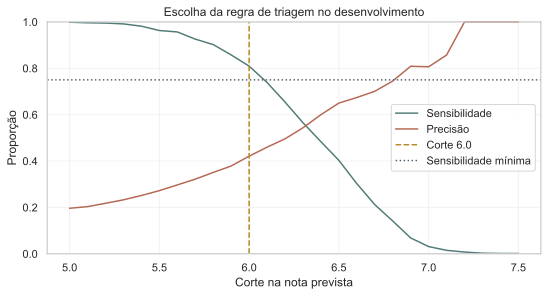

In [9]:
modelo_selecionado = modelos[MODELO_ESCOLHIDO]
previsoes_fora_dobra = cross_val_predict(
    modelo_selecionado, X_desenvolvimento, y_desenvolvimento,
    cv=dobras, n_jobs=1,
)
interesse_desenvolvimento = y_desenvolvimento.to_numpy() >= 7

linhas_corte = []
for corte in np.round(np.arange(5.0, 7.51, 0.1), 1):
    selecionados = previsoes_fora_dobra >= corte
    linhas_corte.append(
        {
            "corte": corte,
            "sensibilidade": recall_score(interesse_desenvolvimento, selecionados, zero_division=0),
            "precisão": precision_score(interesse_desenvolvimento, selecionados, zero_division=0),
            "F1": f1_score(interesse_desenvolvimento, selecionados, zero_division=0),
            "selecionados": int(selecionados.sum()),
        }
    )

curva_corte = pd.DataFrame(linhas_corte)
elegiveis = curva_corte[curva_corte["sensibilidade"] >= 0.75]
CORTE_ESCOLHIDO = float(elegiveis["corte"].max())
linha_corte = curva_corte.loc[curva_corte["corte"].eq(CORTE_ESCOLHIDO)].iloc[0]
display(curva_corte.loc[curva_corte["corte"].between(5.7, 6.3)].round(3))
print("Corte congelado antes do teste:", CORTE_ESCOLHIDO)
print(f"No desenvolvimento: sensibilidade {linha_corte['sensibilidade']:.1%} e precisão {linha_corte['precisão']:.1%}.")

fig, ax = plt.subplots(figsize=(7.5, 4.0), constrained_layout=True)
sns.lineplot(data=curva_corte, x="corte", y="sensibilidade", label="Sensibilidade", color="#527C77", ax=ax)
sns.lineplot(data=curva_corte, x="corte", y="precisão", label="Precisão", color="#B56954", ax=ax)
ax.axvline(CORTE_ESCOLHIDO, color="#B8862B", linestyle="--", label=f"Corte {CORTE_ESCOLHIDO:.1f}")
ax.axhline(0.75, color="#52606D", linestyle=":", label="Sensibilidade mínima")
ax.set(xlabel="Corte na nota prevista", ylabel="Proporção", ylim=(0, 1), title="Escolha da regra de triagem no desenvolvimento")
ax.legend()
plt.show()


### Avaliação final no teste reservado

Com modelo e corte congelados, ajustamos cada candidato nos dados de desenvolvimento e avaliamos no teste. A tabela final permite interpretar o ganho frente à referência, mas não altera a escolha já feita.


In [10]:
linhas_teste = []
previsoes_teste_por_modelo = {}
for nome, modelo in modelos.items():
    modelo.fit(X_desenvolvimento, y_desenvolvimento)
    previsao = modelo.predict(X_teste)
    previsoes_teste_por_modelo[nome] = previsao
    linhas_teste.append(
        {
            "modelo": nome,
            "MAE teste": mean_absolute_error(y_teste, previsao),
            "RMSE teste": mean_squared_error(y_teste, previsao) ** 0.5,
            "R² teste": r2_score(y_teste, previsao),
        }
    )

comparacao_teste = pd.DataFrame(linhas_teste)
comparacao_final = comparacao_validacao.merge(comparacao_teste, on="modelo")
display(
    comparacao_final[["modelo", "MAE VC", "pior dobra", "melhor dobra", "MAE teste", "RMSE teste", "R² teste"]]
    .sort_values("MAE VC").round(3)
)

previsao_teste = previsoes_teste_por_modelo[MODELO_ESCOLHIDO]
selecao_teste = previsao_teste >= CORTE_ESCOLHIDO
interesse_teste = y_teste.to_numpy() >= 7
metricas_operacionais = {
    "sensibilidade": recall_score(interesse_teste, selecao_teste),
    "precisão": precision_score(interesse_teste, selecao_teste),
    "F1": f1_score(interesse_teste, selecao_teste),
    "selecionados": int(selecao_teste.sum()),
    "total": int(len(y_teste)),
    "bons_recuperados": int((selecao_teste & interesse_teste).sum()),
    "bons_total": int(interesse_teste.sum()),
}
display(pd.DataFrame([metricas_operacionais]).round(3))


,modelo,MAE VC,pior dobra,melhor dobra,MAE teste,RMSE teste,R² teste
0,Floresta aleatória,0.531,0.547,0.521,0.529,0.684,0.396
1,k-NN,0.550,0.562,0.542,0.552,0.709,0.351
2,Regressão linear,0.565,0.585,0.548,0.566,0.729,0.313
3,Árvore,0.582,0.619,0.566,0.572,0.737,0.298
4,Referência (mediana),0.643,0.657,0.626,0.643,0.903,-0.053


,sensibilidade,precisão,F1,selecionados,total,bons_recuperados,bons_total
0,0.817,0.447,0.578,369,1064,165,202


## 6. Erros, interpretação e vazamento

O MAE global pode esconder erros nos extremos. Examinamos nota e tipo junto do tamanho de cada grupo. A importância por permutação mede o aumento do MAE ao embaralhar uma entrada no teste: descreve dependência preditiva neste modelo, não causalidade.

O alvo fica fora das entradas; duplicatas completas saem antes da divisão; escala e codificação são ajustadas dentro de cada dobra; modelo e corte são fixados antes do teste. As medidas estão disponíveis antes da triagem.


,n,MAE
nota_real,,
3,6,2.369
4,41,1.211
5,350,0.437
6,465,0.401
7,171,0.647
8,30,1.521
9,1,3.371


,n,MAE
wine_type,,
red,267,0.453
white,797,0.554


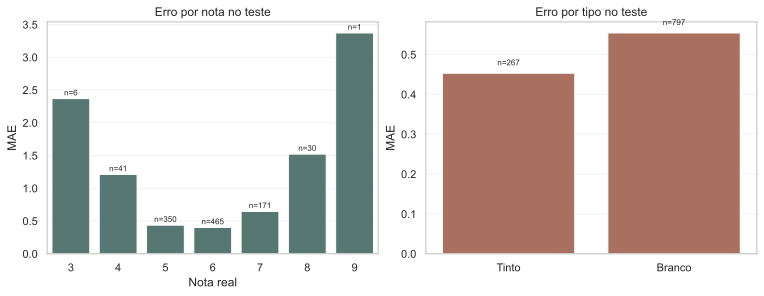

In [11]:
erros = pd.DataFrame(
    {
        "wine_type": X_teste["wine_type"].to_numpy(),
        "nota_real": y_teste.to_numpy(),
        "nota_prevista": previsao_teste,
    },
    index=X_teste.index,
)
erros["erro_absoluto"] = (erros["nota_real"] - erros["nota_prevista"]).abs()

erros_por_nota = erros.groupby("nota_real").agg(n=("erro_absoluto", "size"), MAE=("erro_absoluto", "mean"))
erros_por_tipo = erros.groupby("wine_type").agg(n=("erro_absoluto", "size"), MAE=("erro_absoluto", "mean"))
display(erros_por_nota.round(3))
display(erros_por_tipo.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
sns.barplot(x=erros_por_nota.index.astype(str), y=erros_por_nota["MAE"], color="#527C77", ax=axes[0])
axes[0].set(title="Erro por nota no teste", xlabel="Nota real", ylabel="MAE")
for x, (mae, n) in enumerate(zip(erros_por_nota["MAE"], erros_por_nota["n"])):
    axes[0].text(x, mae + 0.05, f"n={n}", ha="center", fontsize=8)
sns.barplot(x=["Tinto", "Branco"], y=erros_por_tipo.loc[["red", "white"], "MAE"], color="#B56954", ax=axes[1])
axes[1].set(title="Erro por tipo no teste", ylabel="MAE")
for x, tipo in enumerate(["red", "white"]):
    axes[1].text(x, erros_por_tipo.loc[tipo, "MAE"] + 0.02, f"n={erros_por_tipo.loc[tipo, 'n']}", ha="center", fontsize=8)
plt.show()


,variavel,aumento_MAE,desvio
10,alcohol,0.137,0.007
1,volatile acidity,0.057,0.006
5,free sulfur dioxide,0.038,0.004
9,sulphates,0.021,0.003
6,total sulfur dioxide,0.015,0.003
8,pH,0.013,0.002
4,chlorides,0.012,0.002
7,density,0.012,0.002
3,residual sugar,0.010,0.002
2,citric acid,0.009,0.003


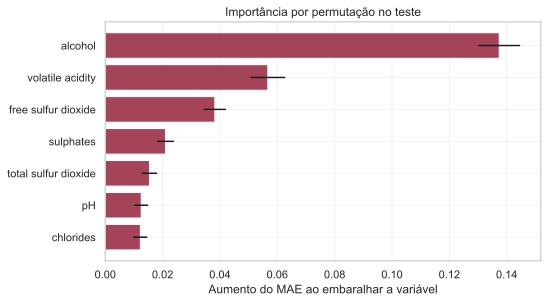

In [12]:
resultado_importancia = permutation_importance(
    modelo_selecionado,
    X_teste,
    y_teste,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=SEMENTE,
    n_jobs=1,
)
importancia = pd.DataFrame(
    {
        "variavel": X_teste.columns,
        "aumento_MAE": resultado_importancia.importances_mean,
        "desvio": resultado_importancia.importances_std,
    }
).sort_values("aumento_MAE", ascending=False)
display(importancia.round(3))

top = importancia.head(7).sort_values("aumento_MAE")
fig, ax = plt.subplots(figsize=(7.5, 4.1), constrained_layout=True)
ax.barh(top["variavel"], top["aumento_MAE"], xerr=top["desvio"], color="#9B3046", alpha=0.9)
ax.set(xlabel="Aumento do MAE ao embaralhar a variável", title="Importância por permutação no teste")
plt.show()


## 7. Uso, limitações e restrições

**Uso pretendido.** A previsão ordena amostras para segunda degustação humana. Falsos negativos deixam vinhos bons fora da prioridade; falsos positivos consomem capacidade do painel.

**Limitações.** Notas 5 e 6 predominam, e os extremos têm poucos casos. A nota é sensorial; faltam safra, produtor, variedade, preço, armazenamento e identificador de amostra. A remoção de duplicatas pode excluir observações legítimas. Diferenças de erro por nota e tipo exigem monitoramento.

**Restrições.** Não usar para aprovar lotes, substituir degustadores, inferir segurança ou preço, nem orientar intervenções químicas. A transferência para outras regiões, variedades, safras, períodos ou laboratórios requer validação externa.


## Respostas rápidas para o banco de perguntas

1. **Referência e ganho:** a referência prevê a mediana do desenvolvimento. Compare seu MAE de teste com o da floresta na tabela final e calcule a redução relativa.
2. **Saída:** o modelo devolve uma nota numérica. Ela responde à pergunta de regressão e ordena amostras.
3. **Decisão:** amostras com previsão de pelo menos 6,0 seguem primeiro para degustação humana.
4. **Métrica:** usamos MAE em pontos de nota. RMSE e R² complementam a leitura.
5. **Erro relevante:** deixar passar um vinho realmente 7 ou maior prejudica a triagem; selecionar um falso positivo consome degustação.
6. **Variáveis:** álcool, acidez volátil e dióxido de enxofre livre aparecem no topo da importância por permutação desta execução.
7. **Generalização:** as mesmas dobras mostram o intervalo de MAE; o teste permaneceu isolado até o final.
8. **Descarte:** removemos 1.177 duplicatas completas; não removemos colunas preditoras.
9. **Informação posterior:** nenhuma entrada depende da nota futura. `quality` fica fora de `X`.
10. **Custo da complexidade:** a floresta reduz o MAE, mas perde a explicação por um único conjunto de coeficientes ou caminho.
11. **Outra divisão:** o resultado mudaria. A dispersão das cinco dobras quantifica parte dessa sensibilidade.
12. **Proibição:** não usar para substituir o painel humano, certificar segurança, definir preço ou extrapolar sem validação.
13. **Modelos testados:** referência, regressão linear, k-NN, árvore e floresta. A escolha usou apenas validação cruzada; o teste veio depois.


## 8. Aplicar a uma nova amostra

A função exige todas as 12 entradas, verifica os valores e devolve a nota estimada e a decisão de prioridade. Uma linha do teste demonstra apenas a interface.


In [13]:
def prever_amostra(amostra):
    if not isinstance(amostra, dict):
        raise TypeError("Informe um dicionário com as entradas da amostra.")
    faltantes = set(X.columns) - set(amostra)
    extras = set(amostra) - set(X.columns)
    if faltantes or extras:
        raise ValueError(f"Entradas faltantes: {sorted(faltantes)}; extras: {sorted(extras)}")
    tabela = pd.DataFrame([amostra], columns=X.columns)
    if tabela.loc[0, "wine_type"] not in {"red", "white"}:
        raise ValueError("wine_type deve ser red ou white.")
    numericas = tabela[COLUNAS_NUMERICAS].apply(pd.to_numeric, errors="raise")
    if not np.isfinite(numericas.to_numpy(dtype=float)).all():
        raise ValueError("As medidas numéricas devem ser finitas.")
    tabela[COLUNAS_NUMERICAS] = numericas
    nota_prevista = float(modelo_selecionado.predict(tabela)[0])
    return {
        "nota_prevista": round(nota_prevista, 3),
        "enviar_para_degustacao_prioritaria": bool(nota_prevista >= CORTE_ESCOLHIDO),
    }

exemplo = X_teste.iloc[0].to_dict()
print(prever_amostra(exemplo))


{'nota_prevista': 5.509, 'enviar_para_degustacao_prioritaria': False}


## 9. Resultados reproduzíveis

As tabelas e métricas são gravadas em CSV e JSON para conferir o relatório. Os gráficos são produzidos no próprio notebook a partir dos dados.


In [14]:
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)
curva_arvore.to_csv(PASTA_RESULTADOS / "curva_arvore.csv", index=False)
tabela_ajustes.to_csv(PASTA_RESULTADOS / "ajustes_modelos.csv", index=False)
comparacao_validacao.to_csv(PASTA_RESULTADOS / "comparacao_validacao.csv", index=False)
comparacao_teste.to_csv(PASTA_RESULTADOS / "comparacao_teste.csv", index=False)
curva_corte.to_csv(PASTA_RESULTADOS / "curva_corte.csv", index=False)
erros_por_nota.to_csv(PASTA_RESULTADOS / "erros_por_nota.csv")
erros_por_tipo.to_csv(PASTA_RESULTADOS / "erros_por_tipo.csv")
importancia.to_csv(PASTA_RESULTADOS / "importancia_permutacao.csv", index=False)

linha_final = comparacao_teste.set_index("modelo").loc[MODELO_ESCOLHIDO]
linha_referencia = comparacao_teste.set_index("modelo").loc["Referência (mediana)"]
resumo = {
    "data_execucao": pd.Timestamp.today().date().isoformat(),
    "random_state": SEMENTE,
    "linhas_originais": int(len(dados_brutos)),
    "duplicatas_removidas": int(len(dados_brutos) - len(base)),
    "linhas_limpas": int(len(base)),
    "linhas_desenvolvimento": int(len(X_desenvolvimento)),
    "linhas_teste": int(len(X_teste)),
    "modelo_escolhido": MODELO_ESCOLHIDO,
    "profundidade_arvore": profundidade_escolhida,
    "k_escolhido": k_escolhido,
    "n_arvores_escolhido": n_arvores_escolhido,
    "corte": CORTE_ESCOLHIDO,
    "mae_teste_modelo": float(linha_final["MAE teste"]),
    "rmse_teste_modelo": float(linha_final["RMSE teste"]),
    "r2_teste_modelo": float(linha_final["R² teste"]),
    "mae_teste_referencia": float(linha_referencia["MAE teste"]),
    "reducao_mae_referencia": float(1 - linha_final["MAE teste"] / linha_referencia["MAE teste"]),
    **{f"triagem_{k}": float(v) if isinstance(v, (float, np.floating)) else int(v) for k, v in metricas_operacionais.items()},
}
(PASTA_RESULTADOS / "resumo_metricas.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2), encoding="utf-8"
)

display(pd.DataFrame([resumo]).T.rename(columns={0: "resultado"}))


,resultado
data_execucao,2026-10-01
random_state,42
linhas_originais,6497
duplicatas_removidas,1177
linhas_limpas,5320
linhas_desenvolvimento,4256
linhas_teste,1064
modelo_escolhido,Floresta aleatória
profundidade_arvore,5
k_escolhido,15
